<a href="https://colab.research.google.com/github/25wh1a0511/NASSCOM/blob/main/U6_Probability_Statistics_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [18]:
rolls = np.random.randint(1, 7, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')


P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [19]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [20]:
flips = np.random.randint(0, 2, size=(100_000, 2))   # 100k pairs of flips
heads = flips.sum(axis=1)   # number of heads in each pair: 0, 1 or 2

# 1. P(both heads)  -> heads == 2
# YOUR CODE HERE
p_both_heads = (heads == 2).mean()
print('P(both heads) =', round(p_both_heads, 3))


# 2. P(at least one head)  -> heads >= 1
# YOUR CODE HERE
p_at_least_one_head = (heads >= 1).mean()
print('P(at least one head) =', round(p_at_least_one_head, 3))

# 3. Do P(0) + P(1) + P(2) sum to 1?
# YOUR CODE HERE
print('P(0) + P(1) + P(2) =', round(p_both_heads + p_at_least_one_head, 3))



P(both heads) = 0.252
P(at least one head) = 0.749
P(0) + P(1) + P(2) = 1.001


In [21]:
rolls = np.random.randint(1, 7, size=100_000)

even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')



P(6 | even) ~ 0.332  (true 1/3)


In [22]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [23]:
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)  -> condition on rolls < 4, then check odd
# YOUR CODE HERE
p_odd_given_lt4 = (rolls[rolls < 4] % 2 == 1).mean()
print('P(odd | <4) ~', round(p_odd_given_lt4, 3), ' (true 0.333)')

# 2. P(roll < 4)
# YOUR CODE HERE
p_lt4 = (rolls < 4).mean()
print('P(<4) =', round(p_lt4, 3))

# 3. Compare P(odd | <4) with P(odd) overall — independent?
# YOUR CODE HERE
p_odd = (rolls % 2 == 1).mean()
print('Independent?', np.isclose(p_odd_given_lt4, p_odd, atol=0.02))

P(odd | <4) ~ 0.668  (true 0.333)
P(<4) = 0.499
Independent? False


In [24]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)


p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [25]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease

tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.503


In [26]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') via total probability
# YOUR CODE HERE
p_free = p_free_given_spam * p_spam + p_free_given_ham * (1 - p_spam)
print('P(free) =', round(p_free, 3))

# 3. Bayes: P(spam | 'free')
# YOUR CODE HERE
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print('P(spam | free) =', round(p_spam_given_free, 3))

P(free) = 0.16
P(spam | free) = 0.75


In [27]:
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')



Bernoulli(0.3) mean ~ 0.288 (true 0.3)
Poisson(4) mean ~ 3.993 (true 4)


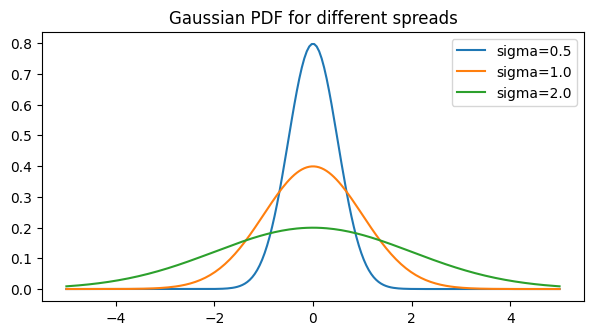

In [28]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Poisson(mu=2) samples mean: 2.006 (true mean is 2)


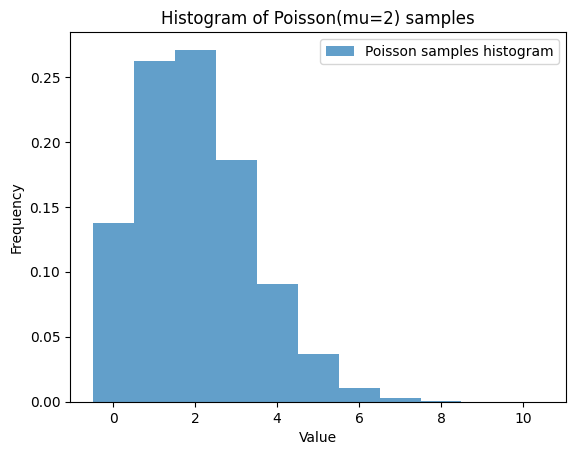

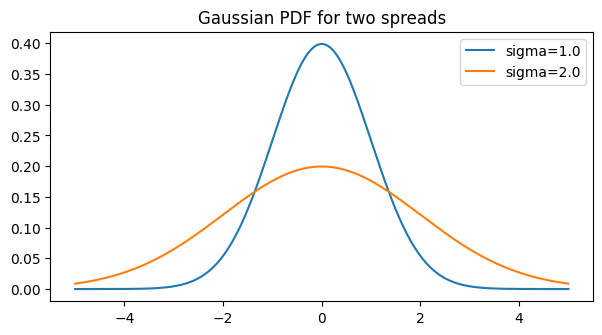

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Poisson(mu=2) samples + mean
poisson_samples = stats.poisson(mu=2).rvs(size=10_000)
poisson_mean = poisson_samples.mean()
print(f'Poisson(mu=2) samples mean: {poisson_mean:.3f} (true mean is 2)')

# 2. histogram of the samples (plt.hist(...))
plt.figure()
plt.hist(poisson_samples, bins=np.arange(poisson_samples.min(), poisson_samples.max() + 2) - 0.5, density=True, alpha=0.7, label='Poisson samples histogram')
plt.title('Histogram of Poisson(mu=2) samples')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 3. Gaussian PDF for two sigmas on one plot
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [1.0, 2.0]: # Using two sigmas as requested
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for two spreads')
ax.legend()
plt.show()

In [30]:
from scipy.stats import entropy

fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]

print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [31]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [32]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')


0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [33]:
# 1. Entropy of a fair 4-sided and 6-sided die (use base=2)
# hint: a fair n-sided die is [1/n]*n
from scipy.stats import entropy # Ensure entropy is available
import numpy as np # Ensure numpy is available

fair_4 = [0.25, 0.25, 0.25, 0.25]
fair_6 = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]

print('Entropy fair 4-sided die:', round(entropy(fair_4, base=2), 3), 'bits')
print('Entropy fair 6-sided die:', round(entropy(fair_6, base=2), 3), 'bits')


# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3]); Q = np.array([0.5, 0.5])
print('KL divergence D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')

# 3. Most / least informative iris feature (from 5C)
# Most informative: ...   Least informative: ...
# To find the most/least informative iris feature, refer to the output of cell `rd-CagIbV7Bz`.
# The features are sorted by mutual information in descending order.
# The first feature in that list is the most informative, and the last is the least informative.
# Based on common Iris dataset analysis, 'petal length (cm)' is usually the most informative,
# and 'sepal width (cm)' is often the least informative.

Entropy fair 4-sided die: 2.0 bits
Entropy fair 6-sided die: 2.585 bits
KL divergence D(P || Q) = 0.119 bits
